# Revisions analyses

## imports and paths

In [1]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import os
import numpy as np
import matplotlib.pyplot as plt

cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
original = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_OA.tsv"), separator="\t")
tempdir = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/"
figdir = cd + "results/manuscript_figures/revisions/"
os.makedirs(tempdir, exist_ok=True)

## 1.1 Setting a DNA count threshold to investigate integration site effects

In [2]:
minDNAcount3 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount3_OA.tsv"), separator="\t")
minDNAcount5 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount5_OA.tsv"), separator="\t")
minDNAcount10 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount10_OA.tsv"), separator="\t")

In [3]:
joint_original_minDNAcounts3 = minDNAcount3.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts5 = minDNAcount5.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts10 = minDNAcount10.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")	

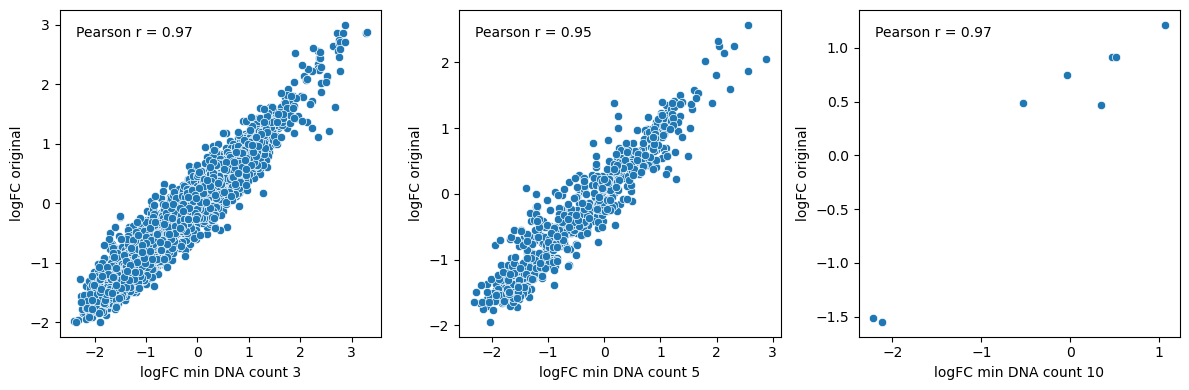

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.scatterplot(
	data=joint_original_minDNAcounts3.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0]
)
axes[0].set_xlabel("logFC min DNA count 3")
axes[0].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts5.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1]
)
axes[1].set_xlabel("logFC min DNA count 5")
axes[1].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts10.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[2]
)
axes[2].set_xlabel("logFC min DNA count 10")
axes[2].set_ylabel("logFC original")
corrs = [
	joint_original_minDNAcounts3.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts5.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts10.select(pl.corr("logFC", "logFC_original")).item()
]

for i, ax in enumerate(axes):
	ax.text(
		0.05, 0.95,
		f"Pearson r = {corrs[i]:.2f}",
		transform=ax.transAxes,
		fontsize=10,
		verticalalignment='top',
		#bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
	)
plt.tight_layout()
#plt.title("logFC comparison original vs minDNAcount3")
plt.savefig(figdir+"/different_DNA_count_thresholds.pdf", format="pdf")

In [20]:
joint_original_minDNAcounts3.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original")), \
joint_original_minDNAcounts5.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original")), \
joint_original_minDNAcounts10.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original"))

(shape: (1, 2)
 ┌──────────┬──────────┐
 │ logFC    ┆ z_score  │
 │ ---      ┆ ---      │
 │ f64      ┆ f64      │
 ╞══════════╪══════════╡
 │ 0.968742 ┆ 0.714213 │
 └──────────┴──────────┘,
 shape: (1, 2)
 ┌──────────┬──────────┐
 │ logFC    ┆ z_score  │
 │ ---      ┆ ---      │
 │ f64      ┆ f64      │
 ╞══════════╪══════════╡
 │ 0.948822 ┆ 0.491722 │
 └──────────┴──────────┘,
 shape: (1, 2)
 ┌─────────┬─────────┐
 │ logFC   ┆ z_score │
 │ ---     ┆ ---     │
 │ f64     ┆ f64     │
 ╞═════════╪═════════╡
 │ 0.97058 ┆ NaN     │
 └─────────┴─────────┘)

In [51]:
# Calculate Jaccard index between 'effect' and 'effect_original'

def rowwise_jaccard_index(df):
	effect = df["effect"].to_list()
	effect_original = df["effect_original"].to_list()
	matches = sum(e == o for e, o in zip(effect, effect_original) if e is not None and e != 'no effect')
	non_matches = sum(e != o for e, o in zip(effect, effect_original) if e is not None and o is not None)
	total = matches + non_matches
	print(matches, non_matches)
	return matches / total if total > 0 else float('nan')


jaccard_index_rowwise_3 = rowwise_jaccard_index(joint_original_minDNAcounts3)
print("Row-wise Jaccard index (minDNAcount3):", jaccard_index_rowwise_3)

jaccard_index_rowwise_5 = rowwise_jaccard_index(joint_original_minDNAcounts5)
print("Row-wise Jaccard index (minDNAcount5):", jaccard_index_rowwise_5)

jaccard_index_rowwise_10 = rowwise_jaccard_index(joint_original_minDNAcounts10)
print("Row-wise Jaccard index (minDNAcount10):", jaccard_index_rowwise_10)

11 45
Row-wise Jaccard index (minDNAcount3): 0.19642857142857142
0 3
Row-wise Jaccard index (minDNAcount5): 0.0
0 0
Row-wise Jaccard index (minDNAcount10): nan


In [30]:
print("Unique values per dataframe:")
print(f"joint_original_minDNAcounts3: {joint_original_minDNAcounts3.n_unique()}")
print(f"joint_original_minDNAcounts5: {joint_original_minDNAcounts5.n_unique()}")
print(f"joint_original_minDNAcounts10: {joint_original_minDNAcounts10.n_unique()}")
print(f"original: {original.n_unique()}")

Unique values per dataframe:
joint_original_minDNAcounts3: 4358
joint_original_minDNAcounts5: 741
joint_original_minDNAcounts10: 8
original: 83501


## 2.2/2.3 Multiple BCs per sequence vs multiple sequences per bin

In [3]:
mpra = original.filter(pl.col("z_score").is_not_null())

<Axes: xlabel='nr_seqs', ylabel='Count'>

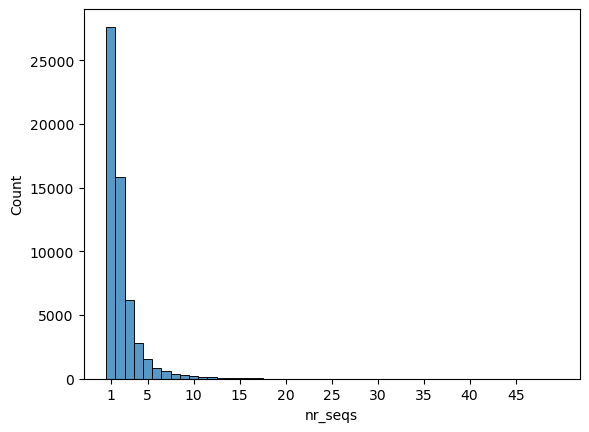

In [75]:
plt.xticks([1] + list(range(5,50, 5)))
sns.histplot(mpra.to_pandas(), x = "nr_seqs", bins=60, discrete=True)


In [8]:
original.filter(pl.col("right_bin").str.contains("null").not_()).filter(pl.col("z_score").is_not_null()).mean()

logFC,adj.P.Val,P.Value,left_bin,right_bin,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std,z_score
f64,f64,f64,str,str,f64,f64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64
-0.14087,0.112279,0.1035,null,null,12.754675,2.149999,null,null,null,null,null,null,null,null,null,154621.880196,null,null,null,null,-0.070059,inf,-0.08884


In [6]:
original.filter(pl.col("right_bin").str.contains("null")).filter(pl.col("targeted_left") != "unlabeled").mean()

logFC,adj.P.Val,P.Value,left_bin,right_bin,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std,z_score
f64,f64,f64,str,str,f64,f64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64
-0.277573,0.095013,0.087753,null,null,130.793212,18.996843,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [4]:
many_bcs = mpra.filter((pl.col("nr_seqs") == 1) & (pl.col("nr_reads") > 20))
many_seqs = mpra.filter((pl.col("nr_seqs") > 6) & (pl.col("nr_seqs") < 30) & (pl.col("nr_reads") < 40))

print(f"Number of barcodes with >20 barcodes and just 1 sequence: {many_bcs.height}")
print(f"Number of sequences with >10 sequences: {many_seqs.height}")

Number of barcodes with >20 barcodes and just 1 sequence: 691
Number of sequences with >10 sequences: 745


In [39]:
many_bcs.select("logFC", "z_score", "adj.P.Val", "nr_reads").mean()

logFC,z_score,adj.P.Val,nr_reads
f64,f64,f64,f64
0.137918,0.216859,0.0582,27.861071


In [12]:
many_seqs.select("logFC", "z_score", "adj.P.Val", "nr_reads", "nr_seqs").mean()

logFC,z_score,adj.P.Val,nr_reads,nr_seqs
f64,f64,f64,f64,f64
-0.211256,-0.348525,0.106507,29.485906,7.869799


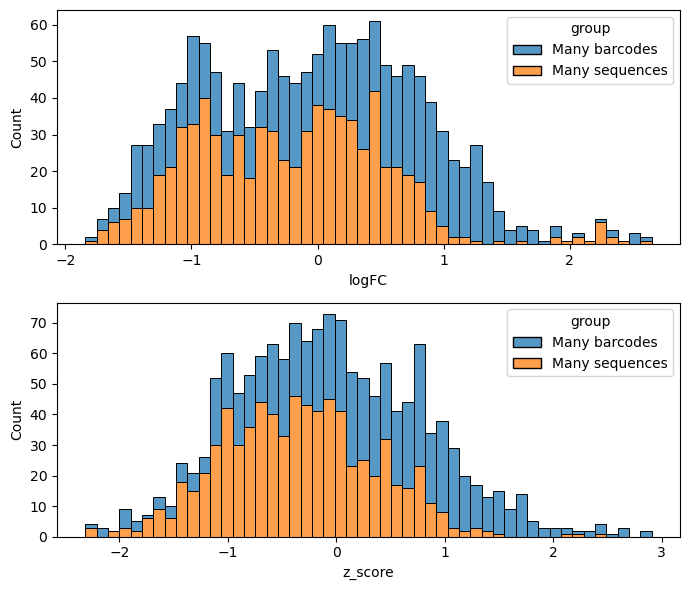

In [42]:
fig, axs = plt.subplots(2,1,figsize=(7, 6))

both = pl.concat([many_bcs, many_seqs]).with_columns(
	pl.when(pl.col("nr_seqs") == 1).then(pl.lit("Many barcodes")).otherwise(pl.lit("Many sequences")).alias("group")
)
sns.histplot(both.to_pandas(), x="logFC", bins=50, hue="group", multiple="stack", ax=axs[0])
sns.histplot(both.to_pandas(), x="z_score", bins=50, hue="group", multiple="stack", ax=axs[1])
plt.tight_layout()

<Axes: xlabel='logFC', ylabel='adj.P.Val'>

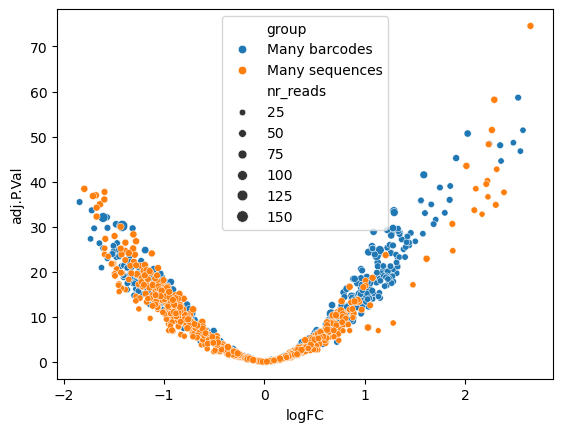

In [45]:
sns.scatterplot(both.with_columns(np.negative(np.log10(pl.col("adj.P.Val")))), x="logFC", y="adj.P.Val", hue="group", size="nr_reads")

### Looking at differences in sequence lengths and coordinates

#### Writing the files

In [7]:
mpra.select("left_bin", "right_bin").write_csv(os.path.join(tempdir, "bins.tsv"), separator="\t", include_header=False)

In [8]:

bins = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv"
seqids = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv"

In [ ]:
# taking only those sequences that had assigned barcodes
!zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/mprasnakeflow/results/assigned_bcs_part1and2.tsv.gz' | cut -f -2,4,6,8,10,12,14 | awk 'NR > 1 && NF >=5' | cut -f 2 | sed 's/>//' > $seqids

In [ ]:
# getting the original sequences for each bin
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-"$8"\t"$9}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/binned/prommoteroa_bins_all.filt_OA.bed.gz') \
		| grep -Fwf <(sed 's/\t/S/' $bins) | sed 's/S/\t/' > "$tempdir""bins_with_seqs.tsv"

In [163]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-"$8"\t"$9}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/binned/prommoteroa_bins_all.filt_OA.bed.gz') \
	| grep -Fwf <(sed 's/\t/S/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv") | sed 's/S/\t/' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_seqs.tsv"

In [ ]:
# Now taking only those sequences with assigned barcodes
!awk '{split($3,seqs,","); for (i in seqs) print $1"\t"$2"\t"seqs[i]}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_seqs.tsv" | sort | uniq -c | awk '{print $2"\t"$3"\t"$4"\t"$5"\t"$1}' | grep -Fwf "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv"

In [ ]:
# getting the full sequence from the mapped file
!samtools view -N  <(cut -f 3 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv") "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/merged_samples.tagged.bam" > \
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam"

In [24]:
!awk -v OFS="\t" '{print $3,$4,$4 + length($10), $1}'  "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam" \
	> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed"

In [25]:
!head "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam" 

m84066_240516_024507_s2/1117240/ccs	16	chr17	10422292	60	256M	*	0	0	CAGATACCCGGGGCACACGGCTGTCAGGGCCTTAAGCACGTTTCCTTATTTGCTACCACGGGAACCCCCCACTGCATTCCCTTGGGCCACTACAGATGCTCACTCTTGAAGTCCAGGCTTAGACAGCAGAGATTCTACCTTGAGTCTCCACCATTGGGCCAGTGCCCACTCATCTAACTTTGAAAAACATTATTAGTAGAAAATAATATGTTTATTACAGAAAAAAATACAGGTAAGTAAAAAAAGTCTCTGTAAG	IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII	NM:i:1	MD:Z:255T0	AS:i:255	XS:i:20	CT:Z:FAR	CO:Z:left
m84066_240516_024507_s2/1117240/ccs	0	chr17	10284356	60	207M	*	0	0	GATCAGCCTGGGCAACATAGTGAGAGCCCTGTCTCTACAAACAAACAAGCAAACAAAAAAATTAGCTAGCTAGGCTTGGTTGTGTGTGCATGTAGTCCCAGCTACTTGGGTGGCTGATGTGAGAGGATTGCTTGAGCCCAGGAGGTCGAAGCAGCTGTGGGCTGTGGTCATGCCACTGCATTCCAGCCCAGGTGACAGAGCAAGATC	IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [26]:
# Bins in the analyzed file are always sorted left to right, so doing that here too to make sure we can join on bins later
!sort -k4,4 -k2,2 -k3,3 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed" | \
	awk -v OFS="\t" '{if ($4 == prev) print $1,prev_start,prev_end,$2,$3,$4; prev=$4; prev_start=$2; prev_end=$3}' \
		> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv"

In [27]:
!wc -l "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv" \
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed"

   91652 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv
  183304 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed
  274956 total


In [28]:
!head "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv"

chr2	99174657	99174970	99180852	99181320	V350161981_L02_contig_100096
chr20	5120285	5120874	5123279	5123477	V350161981_L02_contig_1002303
chr6	151451484	151452400	151452398	151452521	V350161981_L02_contig_1002493
chr12	111599592	111600282	111606115	111606178	V350161981_L02_contig_1002605
chr20	35456447	35456537	35742183	35742569	V350161981_L02_contig_1002901
chr13	45464674	45465113	45481041	45481352	V350161981_L02_contig_1006285
chr2	130835545	130835591	130835945	130836690	V350161981_L02_contig_100659
chr1	45521924	45522331	45537741	45537914	V350161981_L02_contig_1006693
chr6	11232214	11232701	11419894	11420071	V350161981_L02_contig_1007053
chr2	170715320	170715617	170717077	170717451	V350161981_L02_contig_1008084


#### Reading and analyzing the files

In [35]:
bins = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv", 
	separator="\t", columns=[0,1,2],has_header=False, new_columns=["left_bin", "right_bin", "seq_id"])
coords = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv", 
	separator="\t",has_header=False, new_columns=["chrom", "start_left", "end_left", "start_right", "end_right", "seq_id"]) \
	.with_columns(left_length = (pl.col("end_left") - pl.col("start_left") + 1),
	              right_length = (pl.col("end_right") - pl.col("start_right") + 1))

In [64]:
pl.Config.set_fmt_str_lengths(50)
bin_with_coords = bins.join(coords, on="seq_id")
bin_with_coords_stds = bin_with_coords.filter(pl.len().over("left_bin", "right_bin") > 1) \
	.group_by(["left_bin", "right_bin"]).agg(pl.col("left_length", "right_length").std()).unpivot(index=cs.matches("bin"), value_name="length std")


In [65]:
bin_with_coords_stds.head

<bound method DataFrame.head of shape: (58_412, 4)
┌─────────────────────────────┬─────────────────────────────┬──────────────┬────────────┐
│ left_bin                    ┆ right_bin                   ┆ variable     ┆ length std │
│ ---                         ┆ ---                         ┆ ---          ┆ ---        │
│ str                         ┆ str                         ┆ str          ┆ f64        │
╞═════════════════════════════╪═════════════════════════════╪══════════════╪════════════╡
│ chr14-35322114-35322253-.   ┆ chr14-35404489-35405088--   ┆ left_length  ┆ 0.707107   │
│ chr3-186769135-186769185-.  ┆ chr3-186783037-186783473-+  ┆ left_length  ┆ 39.259818  │
│ chr14-34875340-34875553--   ┆ chr14-34898769-34898943-.   ┆ left_length  ┆ 133.643182 │
│ chr20-50920055-50920356-.   ┆ chr20-50958049-50958627--   ┆ left_length  ┆ 2.12132    │
│ chr20-54097488-54097725-.   ┆ chr20-54207771-54208166-+   ┆ left_length  ┆ 79.195959  │
│ …                           ┆ …                

<Axes: xlabel='length std', ylabel='Count'>

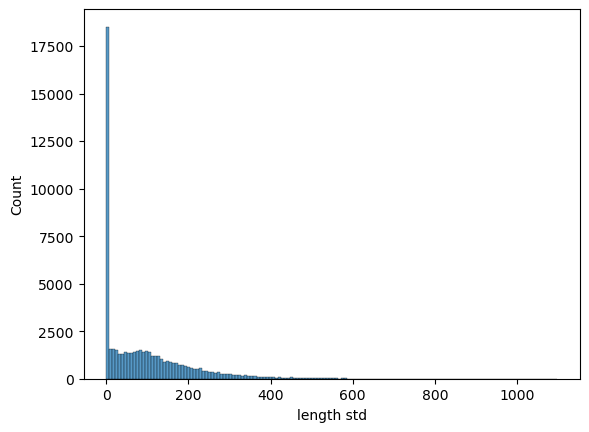

In [66]:
sns.histplot(bin_with_coords_stds.to_pandas(), x="length std")

In [38]:
bin_with_coords.filter(pl.col("left_bin") == "chr18-57621943-57622148--").filter(pl.col("right_bin") == "chr18-57624725-57624896-.")

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length
str,str,str,str,i64,i64,i64,i64,i64,i64
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240516_024507_s2/104468422/ccs""","""chr18""",57621943,57622153,57624728,57624903,211,176
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240516_024507_s2/84347061/ccs""","""chr18""",57621946,57622153,57624536,57624902,208,367
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240623_102831_s3/90574977/ccs""","""chr18""",57621943,57622152,57624534,57624899,210,366
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240623_122801_s1/54137738/ccs""","""chr18""",57621943,57622329,57624743,57624898,387,156
